# Sentiment Analysis with Machine Learning

A machine learning project for sentiment classification using TF-IDF and Logistic Regression.

## Project Overview

This project aims to classify movie reviews as positive or negative using Natural Language Processing (NLP).

We use TF-IDF for feature extraction and Logistic Regression for classification.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [2]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r'<.*?>', '', text)
    text = re.sub(r'[^\w\s]', '', text)
    return text

## Load Dataset

We use the IMDB dataset, which contains movie reviews labeled as positive or negative.

In [3]:
url = "https://raw.githubusercontent.com/laxmimerit/All-CSV-ML-Data-Files-Download/master/IMDB-Dataset.csv"
df = pd.read_csv(url)

df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [4]:
df.shape

(50000, 2)

In [5]:
df['sentiment'].value_counts()

sentiment
positive    25000
negative    25000
Name: count, dtype: int64

In [6]:
df = df.sample(10000, random_state=42).reset_index(drop=True)
df.shape

(10000, 2)

## Data Preprocessing

We clean the text data by converting it to lowercase and removing punctuation and HTML tags.

In [7]:
df['clean_review'] = df['review'].apply(clean_text)

df[['review', 'clean_review']].head()

,review,clean_review
0,I really liked this Summerslam due to the look...,i really liked this summerslam due to the look...
1,Not many television shows appeal to quite as m...,not many television shows appeal to quite as m...
2,The film quickly gets to a major chase scene w...,the film quickly gets to a major chase scene w...
3,Jane Austen would definitely approve of this o...,jane austen would definitely approve of this o...
4,Expectations were somewhat high for me when I ...,expectations were somewhat high for me when i ...


In [8]:
df['sentiment'] = df['sentiment'].map({'negative': 0, 'positive': 1})

df['sentiment'].value_counts()

sentiment
1    5039
0    4961
Name: count, dtype: int64

## Feature Engineering

We convert text into numerical features using TF-IDF (Term Frequency - Inverse Document Frequency).

In [9]:
vectorizer = TfidfVectorizer(max_features=5000, stop_words='english')

X = vectorizer.fit_transform(df['clean_review'])
y = df['sentiment']

print(X.shape)
print(y.shape)

(10000, 5000)
(10000,)


## Model Training

We split the dataset into training and testing sets. The model is trained on the training data and evaluated on unseen test data.

We use Logistic Regression as a baseline model for text classification.

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(y_test.shape)

(2000,)


In [11]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [12]:
y_pred = model.predict(X_test)

## Model Evaluation

We evaluate the model using accuracy, precision, recall, and F1-score.

In [13]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.8685

Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.84      0.86       999
           1       0.85      0.89      0.87      1001

    accuracy                           0.87      2000
   macro avg       0.87      0.87      0.87      2000
weighted avg       0.87      0.87      0.87      2000



## Key Results

- Accuracy: 86.85%
- The model performs well on both positive and negative classes.
- Most errors appear in reviews with mixed sentiment or more subtle wording.

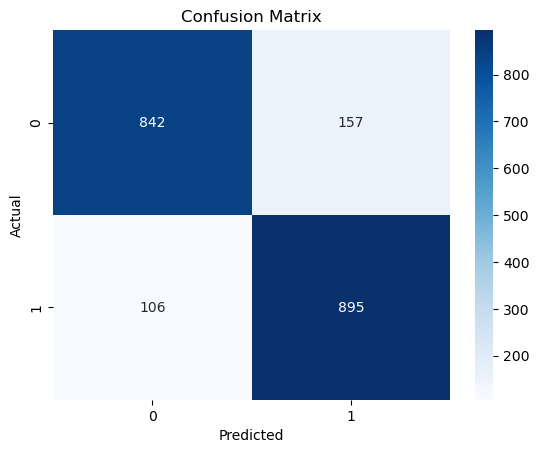

In [14]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

### Confusion Matrix (Percentage)

The normalized confusion matrix helps interpret performance more clearly by showing the proportion of correct and incorrect predictions for each class.

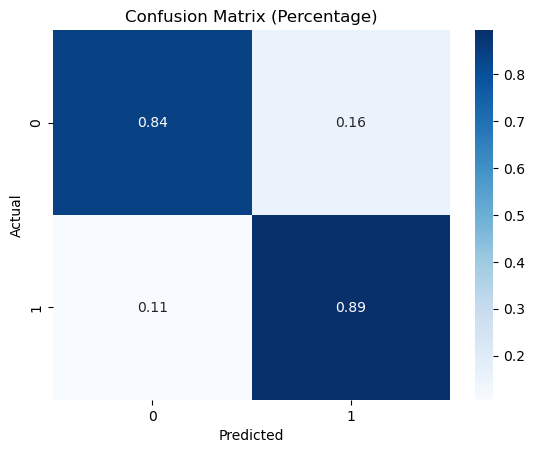

In [18]:
cm = confusion_matrix(y_test, y_pred)

cm_percent = cm / cm.sum(axis=1, keepdims=True)

sns.heatmap(cm_percent, annot=True, fmt='.2f', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix (Percentage)')
plt.show()

The confusion matrix shows that the model correctly classifies most positive and negative reviews, with relatively few misclassifications.

This indicates that the model generalizes well to unseen data.

## Explainability

To better understand the model’s decisions, we analyzed the importance of each word using the coefficients of the Logistic Regression model.

Words with high positive coefficients contribute to positive sentiment predictions, while words with high negative coefficients contribute to negative sentiment.

The results show that the model correctly identifies meaningful sentiment-related words such as "great", "excellent", and "amazing" for positive reviews, and "bad", "worst", and "terrible" for negative reviews.

This indicates that the model has successfully learned relevant patterns from the text data.

In [15]:
feature_names = vectorizer.get_feature_names_out()
coefficients = model.coef_[0]

importance_df = pd.DataFrame({
    'word': feature_names,
    'importance': coefficients
})

print("Top Positive Words:")
print(importance_df.sort_values(by='importance', ascending=False).head(10))

print("\nTop Negative Words:")
print(importance_df.sort_values(by='importance', ascending=True).head(10))

Top Positive Words:
           word  importance
1970      great    5.554521
1555  excellent    4.197159
451        best    3.863807
214     amazing    3.476266
3218    perfect    3.154765
2679      loved    2.958354
1675   favorite    2.920582
1493    enjoyed    2.663016
1850        fun    2.565759
4930  wonderful    2.499839

Top Negative Words:
          word  importance
375        bad   -6.285821
4955     worst   -5.973626
367      awful   -4.637163
4829     waste   -4.492958
3319      poor   -3.611061
4447  terrible   -3.600873
4281    stupid   -3.350891
2171  horrible   -3.278273
4954     worse   -3.196918
528     boring   -3.175405


## Error Analysis

Some reviews are misclassified, often due to complex language such as sarcasm or mixed sentiment.

This highlights limitations of the model when dealing with nuanced text.

In [22]:
misclassified = df.iloc[y_test.index][y_test != y_pred]

misclassified[['review', 'sentiment']].head(5)

,review,sentiment
4742,"Yes, the votes are in. This film may very well...",0
576,I saw this movie when i was much younger and i...,0
7487,This film is supposedly about three young idea...,0
6033,What was always missing with the Matrix story ...,1
8362,While the premise of the film is pretty lame (...,1


Some misclassified examples may contain mixed sentiment, subtle wording, or context that is harder for a linear model to interpret.

## Model Usage

We test the model on custom input sentences to demonstrate how it can be used in practice.

In [19]:
def predict_sentiment(text):
    cleaned = clean_text(text)
    vectorized = vectorizer.transform([cleaned])
    prediction = model.predict(vectorized)[0]
    
    return "Positive" if prediction == 1 else "Negative"

# δοκιμές
print(predict_sentiment("This movie was amazing, I loved it"))
print(predict_sentiment("Worst film ever, total waste of time"))

Positive
Negative


In [20]:
print(predict_sentiment("I expected more from this movie, it was disappointing"))

Negative


In [21]:
print(predict_sentiment("This was one of the best movies I have ever seen"))

Positive


### Prediction Confidence

We also estimate the model's confidence for a given prediction using predicted probabilities.

In [24]:
label, confidence = predict_with_confidence("This movie was okay but not great")
print("Prediction:", label)
print("Confidence:", round(confidence, 3))

Prediction: Positive
Confidence: 0.752


## Future Improvements

Possible next steps for improving this project include:

- comparing Logistic Regression with other models such as Naive Bayes or SVM
- using hyperparameter tuning for better performance
- applying more advanced NLP models such as LSTM or Transformer-based architectures
- improving handling of sarcasm, ambiguity, and mixed sentiment

## Conclusion

The model achieved an accuracy of 86.85%, showing strong performance in sentiment classification.

The results demonstrate that TF-IDF combined with Logistic Regression is effective for text classification tasks.

This project showcases a complete NLP pipeline from preprocessing to prediction and basic model interpretation.